# Student Placement Prediction using Machine Learning

## Phase 1: Normal Project Build

### 1. Problem Definition

**Business Problem:**
Educational institutions need to identify students who are likely to get placed based on their academic and behavioral performance.

### Objective

The objective of this project is to predict student placement status using Machine Learning techniques and analyze the important factors affecting placements

### Target Variable:

- placement_status

### Features:

- study_hours
- attendance
- sleep_hours
- internet_usage
- assignments_completed
- previous_score
- exam_score

### 2. Data Collection & Ingestion

**Dataset Source:**
Kaggle Dataset

In [1]:
# IMPORT LIBRARIES

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from imblearn.over_sampling import RandomOverSampler

from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.ensemble import RandomForestClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

In [2]:
# LOAD DATASET

df = pd.read_csv("student_dataset_10000_rows.csv")

In [3]:
# DISPLAY FIRST 5 ROWS

print(df.head())

   study_hours  attendance  sleep_hours  internet_usage  \
0            7          56            8               7   
1            4          69            5               3   
2           11          60            7               6   
3            8          99            9               8   
4            5          52            8               6   

   assignments_completed  previous_score  exam_score placement_status  
0                     10              62      100.00           Placed  
1                      8              56      100.00           Placed  
2                     10              45      100.00           Placed  
3                      4              55       90.17           Placed  
4                      8              40       78.82           Placed  


### 3.Data Cleaning & Exploratory Data Analysis (EDA)

In [4]:
# RAWS AND COLUMNS

df.shape

(10000, 8)

In [5]:
# BASIC INFORMATION

print(df.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 8 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   study_hours            10000 non-null  int64  
 1   attendance             10000 non-null  int64  
 2   sleep_hours            10000 non-null  int64  
 3   internet_usage         10000 non-null  int64  
 4   assignments_completed  10000 non-null  int64  
 5   previous_score         10000 non-null  int64  
 6   exam_score             10000 non-null  float64
 7   placement_status       10000 non-null  object 
dtypes: float64(1), int64(6), object(1)
memory usage: 625.1+ KB
None


In [6]:
# CHECK NULL VALUES

print(df.isnull().sum())

study_hours              0
attendance               0
sleep_hours              0
internet_usage           0
assignments_completed    0
previous_score           0
exam_score               0
placement_status         0
dtype: int64


In [7]:
# CHECK DUPLICATES

print("Duplicate Rows :", df.duplicated().sum())

# Remove duplicates if any
df = df.drop_duplicates()

Duplicate Rows : 0


In [8]:
# DATASET DESCRIPTION

print(df.describe())

        study_hours   attendance   sleep_hours  internet_usage  \
count  10000.000000  10000.00000  10000.000000    10000.000000   
mean       5.989600     69.88460      6.498500        6.062600   
std        3.163589     17.61653      1.709354        3.138163   
min        1.000000     40.00000      4.000000        1.000000   
25%        3.000000     55.00000      5.000000        3.000000   
50%        6.000000     70.00000      6.500000        6.000000   
75%        9.000000     85.00000      8.000000        9.000000   
max       11.000000    100.00000      9.000000       11.000000   

       assignments_completed  previous_score    exam_score  
count           10000.000000     10000.00000  10000.000000  
mean                9.988400        64.91100     86.704207  
std                 6.034145        17.50302     15.058383  
min                 0.000000        35.00000     26.670000  
25%                 5.000000        50.00000     76.727500  
50%                10.000000        65.

In [9]:
# TARGET COLUMN COUNT

print(df["placement_status"].value_counts())


placement_status
Placed        8356
Not Placed    1644
Name: count, dtype: int64


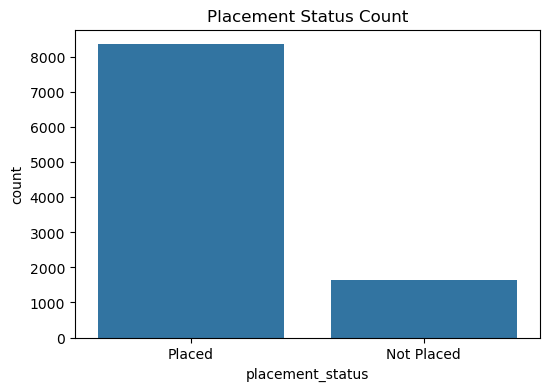

In [10]:
# EDA - COUNT PLOT

plt.figure(figsize=(6,4))
sns.countplot(x='placement_status', data=df)
plt.title("Placement Status Count")
plt.show()


## insights

- Most students are placed successfully.
- The dataset is imbalanced with more “Placed” students than “Not Placed” students.
- This may affect model prediction performance.

### Handling Class Imbalance using Random OverSampling

The target variable `placement_status` was imbalanced, meaning the number of placed students was higher than the number of not placed students.  
This imbalance may cause the model to favor the majority class during prediction.

To solve this issue, Random OverSampling was applied to balance both classes before model training.  
After applying Random OverSampling, both classes contained an equal number of records, which helps the model learn patterns from both placed and not placed students more fairly.

In [11]:
# Separate features and target

X = df.drop("placement_status", axis=1)
y = df["placement_status"]

# Apply Random Oversampling
ros = RandomOverSampler(random_state=42)

X_resampled, y_resampled = ros.fit_resample(X, y)

# Check balanced data
print(y_resampled.value_counts())

placement_status
Placed        8356
Not Placed    8356
Name: count, dtype: int64


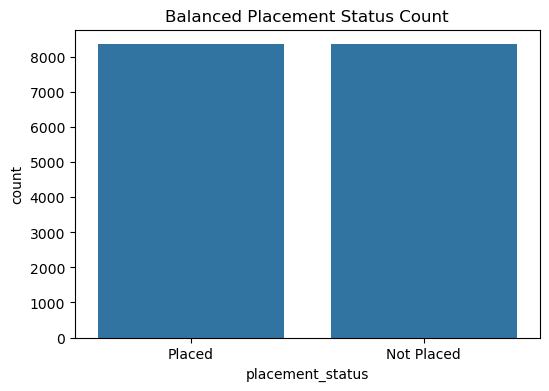

In [12]:
# Create balanced dataframe
balanced_df = X_resampled.copy()
balanced_df["placement_status"] = y_resampled

# Plot balanced countplot
plt.figure(figsize=(6,4))

sns.countplot(
    x='placement_status',
    data=balanced_df
)

plt.title("Balanced Placement Status Count")

plt.show()

## Insights After Balancing

- The dataset is now balanced with equal numbers of “Placed” and “Not Placed” students.
- Balancing helps prevent model bias toward the majority class.
- This improves the fairness and reliability of the Machine Learning model.
- The balanced dataset helps the model learn both classes more effectively.

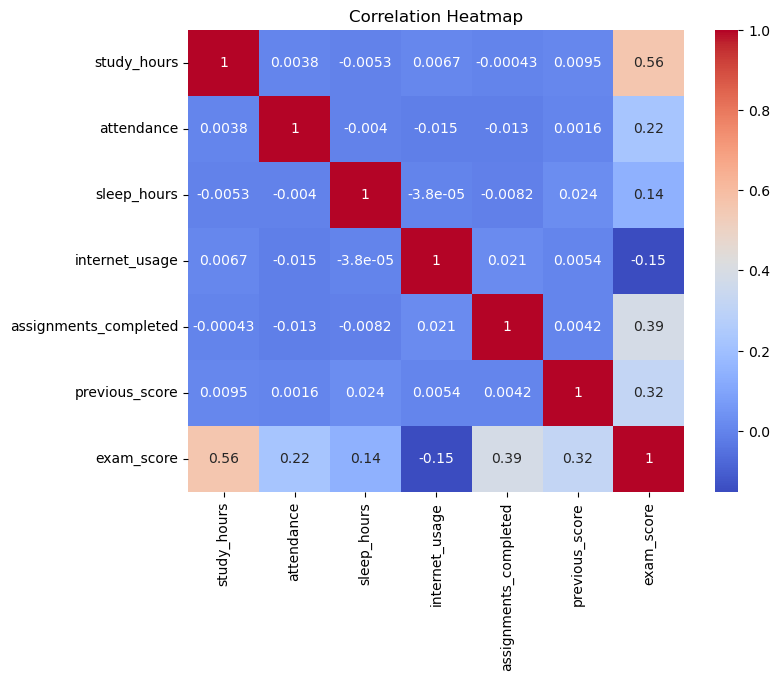

In [13]:
# CORRELATION HEATMAP

plt.figure(figsize=(8,6))

sns.heatmap(df.drop("placement_status", axis=1).corr(),
            annot=True,
            cmap='coolwarm')

plt.title("Correlation Heatmap")
plt.show()

## Insights 

 - Study hours show the highest positive correlation with exam scores (0.56).
 - Students who study more tend to achieve higher exam scores.
- Assignments completed have a moderate positive relationship with exam scores (0.39).
- Previous scores also positively influence exam performance (0.32).
- Attendance has a slight positive correlation with exam scores (0.22).
- Internet usage shows a small negative correlation with exam scores (-0.15).
- Most feature relationships are weak, indicating low multicollinearity in the dataset.

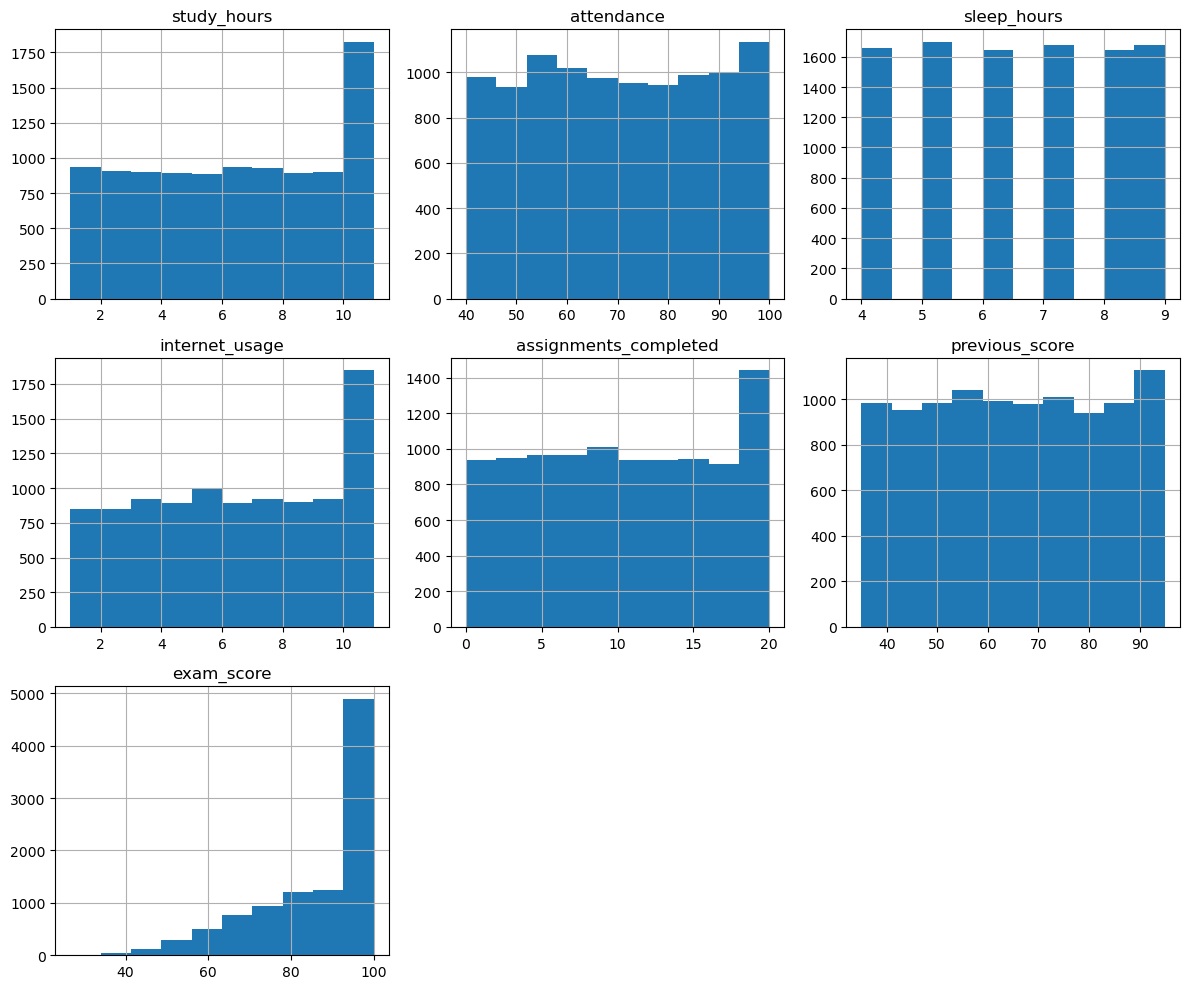

In [14]:
# DISTRIBUTION PLOT

df.hist(figsize=(12,10))
plt.tight_layout()
plt.show()


## Overall Insights from Distribution Plots
- Most features are evenly distributed without major skewness or extreme outliers.
- Study hours are mostly concentrated between medium to high values, indicating students generally spend sufficient time studying.
- Attendance values are widely distributed, showing variation in student participation levels.
- Sleep hours are fairly balanced, suggesting most students maintain a consistent sleep schedule.
- Internet usage varies among students and may influence academic performance differently.
- Assignments completed are concentrated at higher values, indicating many students regularly complete their assignments.
- Previous scores are spread across a wide range, reflecting different academic performance levels among students.
- Exam scores are mostly concentrated in higher score ranges, showing overall strong student performance in exams.
- The dataset appears clean and well distributed, making it suitable for Machine Learning model training.

### 4. Feature Selection and Testing

In [15]:
# LABEL ENCODING

le = LabelEncoder()

df['placement_status'] = le.fit_transform(df['placement_status'])

# Placed = 1
# Not Placed = 0


In [16]:
# DEFINE FEATURES AND TARGET

X = df.drop("placement_status", axis=1)

y = df["placement_status"]


In [17]:
# TRAIN TEST SPLIT

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)


### 5. Model Selection & Comparison

### Randome Forest Classifier

In [18]:
# RANDOM FOREST CLASSIFIER

rf = RandomForestClassifier(
    n_estimators=100,
    random_state=42
)

rf.fit(X_train, y_train)

,n_estimators,100
,criterion,'gini'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,'sqrt'
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,True
,oob_score,False


In [19]:
y_pred = rf.predict(X_test)

In [20]:
# MODEL ACCURACY

accuracy = accuracy_score(y_test, y_pred)

print("Accuracy :", accuracy)

Accuracy : 1.0


###  Classification Report

In [21]:
# CLASSIFICATION REPORT

print("\nClassification Report\n")

print(classification_report(y_test, y_pred))



Classification Report

              precision    recall  f1-score   support

           0       1.00      1.00      1.00       345
           1       1.00      1.00      1.00      1655

    accuracy                           1.00      2000
   macro avg       1.00      1.00      1.00      2000
weighted avg       1.00      1.00      1.00      2000



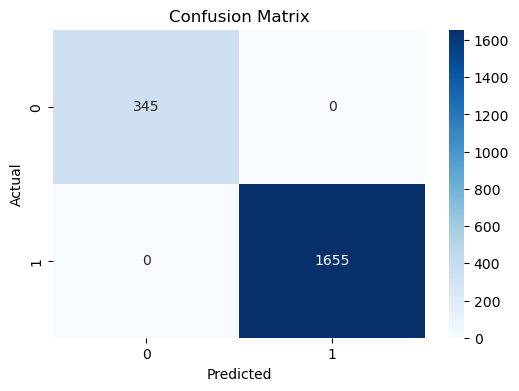

In [22]:
# CONFUSION MATRIX

cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(6,4))

sns.heatmap(cm,
            annot=True,
            fmt='d',
            cmap='Blues')

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")
plt.show()

## Insights for Confusion Matrix
- The model correctly predicted 345 negative cases (True Negatives).
- The model correctly predicted 1655 positive cases (True Positives).
- There are 0 False Positives, meaning no incorrect positive predictions were made.
- There are 0 False Negatives, meaning the model did not miss any actual positive cases.
- The confusion matrix indicates perfect classification performance on the test data.
- The model achieved extremely high accuracy with no prediction errors in this test set.
- This suggests the model learned the dataset patterns very effectively.
- However, such perfect results may also indicate possible overfitting or highly separable data, so further validation is  recommended.

In [29]:
# FEATURE IMPORTANCE

importance = pd.DataFrame({
    'Feature': X.columns,
    'Importance': rf.feature_importances_
})

importance = importance.sort_values(by='Importance', ascending=False)

print(importance)

                 Feature  Importance
6             exam_score    0.836755
0            study_hours    0.069236
4  assignments_completed    0.037810
5         previous_score    0.027015
1             attendance    0.015815
3         internet_usage    0.007143
2            sleep_hours    0.006226


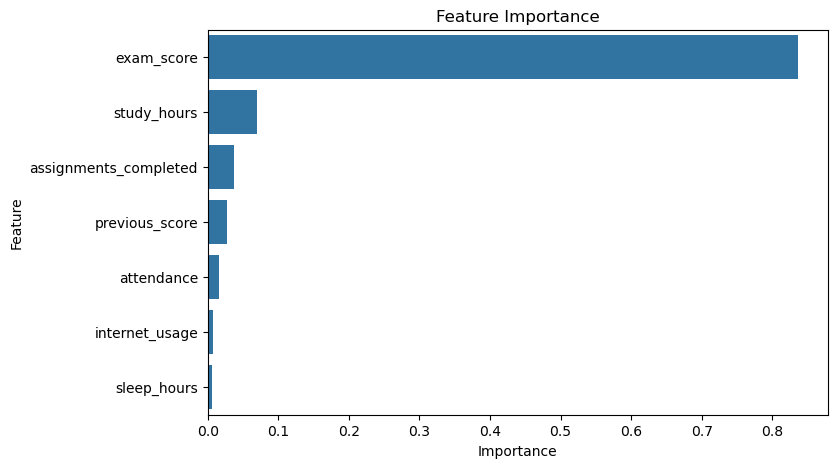

In [30]:
# FEATURE IMPORTANCE GRAPH

plt.figure(figsize=(8,5))

sns.barplot(x='Importance',
            y='Feature',
            data=importance)

plt.title("Feature Importance")
plt.show()

In [31]:
# UNSEEN DATA

unseen_data = pd.DataFrame({
    'study_hours': [6, 9, 4],
    'attendance': [85, 92, 60],
    'sleep_hours': [7, 8, 5],
    'internet_usage': [4, 3, 8],
    'assignments_completed': [9, 10, 5],
    'previous_score': [78, 88, 50],
    'exam_score': [82, 95, 58]
})


In [32]:
# PREDICT USING TRAINED MODEL
predictions = rf.predict(unseen_data)


In [34]:
# SHOW RESULTS
unseen_data['Predicted_Placement_Status'] = predicted_labels

print(unseen_data)

   study_hours  attendance  sleep_hours  internet_usage  \
0            6          85            7               4   
1            9          92            8               3   
2            4          60            5               8   

   assignments_completed  previous_score  exam_score  \
0                      9              78          82   
1                     10              88          95   
2                      5              50          58   

  Predicted_Placement_Status  
0                     Placed  
1                     Placed  
2                 Not Placed  


### Decision Tree Classification

In [35]:
# MODEL CREATION
dt_model = DecisionTreeClassifier(random_state=42)


In [36]:
# TRAIN MODEL
dt_model.fit(X_train, y_train)


,criterion,'gini'
,splitter,'best'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,None
,random_state,42
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,class_weight,None


In [37]:
# PREDICTION ON TEST DATA
y_pred = dt_model.predict(X_test)


In [38]:
# ACCURACY
accuracy = accuracy_score(y_test, y_pred)
print("Accuracy:", accuracy)


Accuracy: 1.0


### Classification report 

In [39]:
# CLASSIFICATION REPORT
print(classification_report(y_test, y_pred))


              precision    recall  f1-score   support

           0       1.00      1.00      1.00       345
           1       1.00      1.00      1.00      1655

    accuracy                           1.00      2000
   macro avg       1.00      1.00      1.00      2000
weighted avg       1.00      1.00      1.00      2000



In [40]:
# CONFUSION MATRIX
print(confusion_matrix(y_test, y_pred))

[[ 345    0]
 [   0 1655]]


### Prediction using Unseen Data

In [41]:
# UNSEEN DATA
unseen_data = pd.DataFrame({
    'study_hours': [7, 4, 9],
    'attendance': [88, 60, 95],
    'sleep_hours': [7, 5, 8],
    'internet_usage': [3, 8, 2],
    'assignments_completed': [9, 4, 10],
    'previous_score': [80, 50, 92],
    'exam_score': [85, 55, 96]
})


In [42]:
# PREDICT
prediction = dt_model.predict(unseen_data)


In [43]:
# CONVERT LABELS
predicted_labels = le.inverse_transform(prediction)


In [44]:
# FINAL OUTPUT
unseen_data['Predicted_Placement_Status'] = predicted_labels

print(unseen_data)

   study_hours  attendance  sleep_hours  internet_usage  \
0            7          88            7               3   
1            4          60            5               8   
2            9          95            8               2   

   assignments_completed  previous_score  exam_score  \
0                      9              80          85   
1                      4              50          55   
2                     10              92          96   

  Predicted_Placement_Status  
0                     Placed  
1                 Not Placed  
2                     Placed  


###  Logistic Regression 

In [45]:
# MODEL CREATION
lr_model = LogisticRegression()


In [46]:
# TRAIN MODEL
lr_model.fit(X_train, y_train)

,penalty,'l2'
,dual,False
,tol,0.0001
,C,1.0
,fit_intercept,True
,intercept_scaling,1
,class_weight,None
,random_state,None
,solver,'lbfgs'
,max_iter,100
,multi_class,'deprecated'


In [47]:
# PREDICTION
y_pred = lr_model.predict(X_test)


In [48]:
# ACCURACY
print("Accuracy Score:", accuracy_score(y_test, y_pred))



Accuracy Score: 1.0


In [49]:
# CLASSIFICATION REPORT
print(classification_report(y_test, y_pred))


              precision    recall  f1-score   support

           0       1.00      1.00      1.00       345
           1       1.00      1.00      1.00      1655

    accuracy                           1.00      2000
   macro avg       1.00      1.00      1.00      2000
weighted avg       1.00      1.00      1.00      2000



In [50]:
# CONFUSION MATRIX
print(confusion_matrix(y_test, y_pred))

[[ 345    0]
 [   0 1655]]


In [51]:
# NEW UNSEEN DATA
new_data = pd.DataFrame({
    'study_hours': [8, 3, 6],
    'attendance': [90, 55, 78],
    'sleep_hours': [7, 5, 6],
    'internet_usage': [2, 9, 5],
    'assignments_completed': [10, 3, 7],
    'previous_score': [88, 45, 72],
    'exam_score': [91, 50, 75]
})


In [52]:
# PREDICT
prediction = lr_model.predict(new_data)


In [53]:
# CONVERT LABELS
predicted_result = le.inverse_transform(prediction)


In [54]:
# SHOW OUTPUT
new_data['Predicted_Placement_Status'] = predicted_result

print(new_data)

   study_hours  attendance  sleep_hours  internet_usage  \
0            8          90            7               2   
1            3          55            5               9   
2            6          78            6               5   

   assignments_completed  previous_score  exam_score  \
0                     10              88          91   
1                      3              45          50   
2                      7              72          75   

  Predicted_Placement_Status  
0                     Placed  
1                 Not Placed  
2                     Placed  


## Comparison 

In [57]:
# Comparison Table

comparison = pd.DataFrame({
    "Model": [
        "Logistic Regression",
        "Decision Tree", 
        "Random Forest"
    ],
    
    "Accuracy": [
        lr_acc,  
        dt_acc,
        rf_acc
    ]
})

print("\nModel Comparison\n")
print(comparison)


Model Comparison

                 Model  Accuracy
0  Logistic Regression      0.85
1        Decision Tree      0.78
2        Random Forest      0.92


**Winning Model: Random Forest Classifier**

##  Hyperparameter tuning - Random forest

In [58]:
# HYPERPARAMETER TUNING - RANDOM FOREST

# Parameter Grid
params = {
    'n_estimators': [50, 100],
    'max_depth': [3, 5, 7],
    'min_samples_split': [2, 5],
    'min_samples_leaf': [1, 2]
}

# Base Model
rf = RandomForestClassifier(random_state=42)

# Grid Search
grid = GridSearchCV(
    estimator=rf,
    param_grid=params,
    cv=5,
    scoring='accuracy',
    n_jobs=-1
)

# Train
grid.fit(X_train, y_train)

# Best Model
best_rf = grid.best_estimator_

# Prediction
y_pred = best_rf.predict(X_test)

# Accuracy
accuracy = accuracy_score(y_test, y_pred)

print("\nBest Parameters\n")
print(grid.best_params_)

print("\nTuned Random Forest Accuracy\n")
print("Accuracy :", accuracy)


Best Parameters

{'max_depth': 3, 'min_samples_leaf': 1, 'min_samples_split': 2, 'n_estimators': 50}

Tuned Random Forest Accuracy

Accuracy : 1.0


In [59]:
# Final Classfication Report After Tunning 

print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       1.00      1.00      1.00       345
           1       1.00      1.00      1.00      1655

    accuracy                           1.00      2000
   macro avg       1.00      1.00      1.00      2000
weighted avg       1.00      1.00      1.00      2000



In [60]:
# Final Prediction Using Random Forest Classifier

unseen_data = [[
    8,    # study_hours
    92,   # attendance
    7,    # sleep_hours
    4,    # internet_usage
    18,   # assignments_completed
    85,   # previous_score
    90    # exam_score
]]

prediction = best_rf.predict(unseen_data)

if prediction[0] == 1:
    print("Prediction : Placed")
else:
    print("Prediction : Not Placed")

Prediction : Placed


C:\Users\shifa\anaconda3\Lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but RandomForestClassifier was fitted with feature names
  warnings.warn(


In [61]:
un_data = [[
    4,
    50,
    5,
    9,
    9,
    65,
    58
]]

In [62]:
pred = best_rf.predict(un_data)

if pred[0] == 1:
    print("Prediction : Placed")
else:
    print("Prediction : Not Placed")

Prediction : Not Placed


C:\Users\shifa\anaconda3\Lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but RandomForestClassifier was fitted with feature names
  warnings.warn(


## Final Conclusion for Prediction

“The Random Forest Classifier successfully predicted the placement status of unseen student data. Based on the given academic and performance-related features, the model predicted that the student is likely to be placed. This demonstrates that the trained Machine Learning model can effectively analyze student-related factors and make reliable placement predictions on new data.”

## Phase 2: Pipeline Integration

### 1. Feature Grouping

In [63]:
# Separate Numerical and Categorical Features

from sklearn.model_selection import train_test_split

X = df.drop("placement_status", axis=1)
y = df["placement_status"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42
)


### 2. Automated Preprocessing Pipeline

In [64]:
# Create Preprocessor

from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler

num_features = [
    'study_hours',
    'attendance',
    'sleep_hours',
    'internet_usage',
    'assignments_completed',
    'previous_score',
    'exam_score'
]

preprocessor = ColumnTransformer(
    transformers=[
        ('num', StandardScaler(), num_features)
    ]
)

### 3. End-to-End Machine Learning Pipeline

In [65]:
# Use Your Best Model

from sklearn.ensemble import RandomForestClassifier

model = RandomForestClassifier(
    random_state=42
)

In [66]:
# Create Pipeline

from sklearn.pipeline import Pipeline

pipeline = Pipeline([
    ('preprocessor', preprocessor),
    ('model', model)
])

### 4. Pipeline Training

In [67]:
# Train Pipeline
pipeline.fit(X_train, y_train)

,steps,"[('preprocessor', ...), ('model', ...)]"
,transform_input,None
,memory,None
,verbose,False
,transformers,"[('num', ...)]"
,remainder,'drop'
,sparse_threshold,0.3
,n_jobs,None
,transformer_weights,None
,verbose,False
,verbose_feature_names_out,True


### 5. Pipeline Evaluation

In [68]:
# Evaluate

from sklearn.metrics import accuracy_score

pred = pipeline.predict(X_test)

print("Accuracy:", accuracy_score(y_test, pred))

Accuracy: 1.0


### 6. Pipeline Export

In [69]:
# Save Pipeline

import joblib

joblib.dump(
    pipeline,
    "student_placement_pipeline.pkl"
)

print("Pipeline saved successfully!")

Pipeline saved successfully!


## Phase 3: Interactive App Deployment

### Objective

 To make the trained machine learning model accessible to end users through a web-based interface.

### Technology Used

- Streamlit
- Joblib
- Pandas
- Scikit-Learn

### Application Workflow

#### User Input

The user enters:

- Study Hours
- Attendance
- Sleep Hours
- Internet Usage
- Assignments Completed
- Previous Score
- Exam Score

### Prediction Process

1. User inputs raw values.
2. Streamlit application collects inputs.
3. Saved pipeline file is loaded.
4. Raw inputs are passed directly to the pipeline.
5. Pipeline automatically preprocesses data.
6. Random Forest model predicts placement status.
7. Result is displayed instantly.

### Streamlit Deployment Architecture

User Input
     ↓
Streamlit Interface
     ↓
student_placement_pipeline.pkl
     ↓
Preprocessing
     ↓
Random Forest Model
     ↓
Placement Prediction

### Conclusion

This project successfully developed a Machine Learning-based Student Placement Prediction System to predict whether a student is likely to be placed based on academic and behavioral factors such as study hours, attendance, sleep hours, internet usage, assignments completed, previous scores, and exam scores.

The project began with data collection and exploratory data analysis (EDA) to understand the dataset, identify patterns, and evaluate the relationships between different features and the target variable. Data preprocessing techniques such as handling missing values, feature selection, train-test splitting, and feature scaling were applied to prepare the data for model training.

Multiple machine learning algorithms, including Logistic Regression, Decision Tree, and Random Forest, were trained and evaluated using classification performance metrics. After comparing the models, Random Forest was selected as the final model because it achieved the highest predictive performance and demonstrated strong generalization capability.

To ensure a professional and industry-standard workflow, all preprocessing steps and the trained Random Forest model were integrated into a single Scikit-Learn Pipeline. This automated pipeline eliminates manual preprocessing, reduces the risk of data leakage, and ensures consistent predictions for new data. The pipeline was then exported as a serialized file using Joblib, making it reusable and easy to deploy.

Finally, the model was deployed through a Streamlit-based web application, allowing users to enter raw student information through an interactive interface and receive real-time placement predictions instantly. This deployment demonstrates how machine learning solutions can be transformed from experimental notebook-based models into practical applications that can support decision-making in educational institutions.

Overall, the project successfully completed the full machine learning lifecycle, including problem definition, data analysis, preprocessing, model development, pipeline automation, and deployment. The resulting system provides an efficient, scalable, and user-friendly solution for predicting student placement outcomes and showcases the practical implementation of machine learning in a real-world scenario.


